# Visualize Stroke Predictions

Load a trained checkpoint and see what the model generates from test images.

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from model import InkStrokePredictor
from dataset import create_dataloaders
from metrics import render_trajectory, compute_all_metrics

DATA_PATH = "/Users/artemlukoyanov/Documents/Proga/Ilumni/playground/SundaiClub/weeks/inkai/ink-ai-hack-playground/notebooks/data/generated/dataset.npz"
CHECKPOINT_PATH = "checkpoints/best.pt"

# Device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Device: {device}")

# Load model
model = InkStrokePredictor(feature_dim=256, num_mixtures=20, num_layers=2).to(device)
ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded checkpoint from epoch {ckpt.get('epoch', '?')}")

# Load test split
_, _, test_loader = create_dataloaders(DATA_PATH, batch_size=1, val_split=0.1, test_split=0.1)
print(f"Test set: {len(test_loader.dataset)} samples")

Device: mps
Loaded checkpoint from epoch 20
Test set: 200 samples


## Sample predictions

Each row: **input image** | **target trajectory** | **predicted trajectory** | **overlay** (pred in red on input)

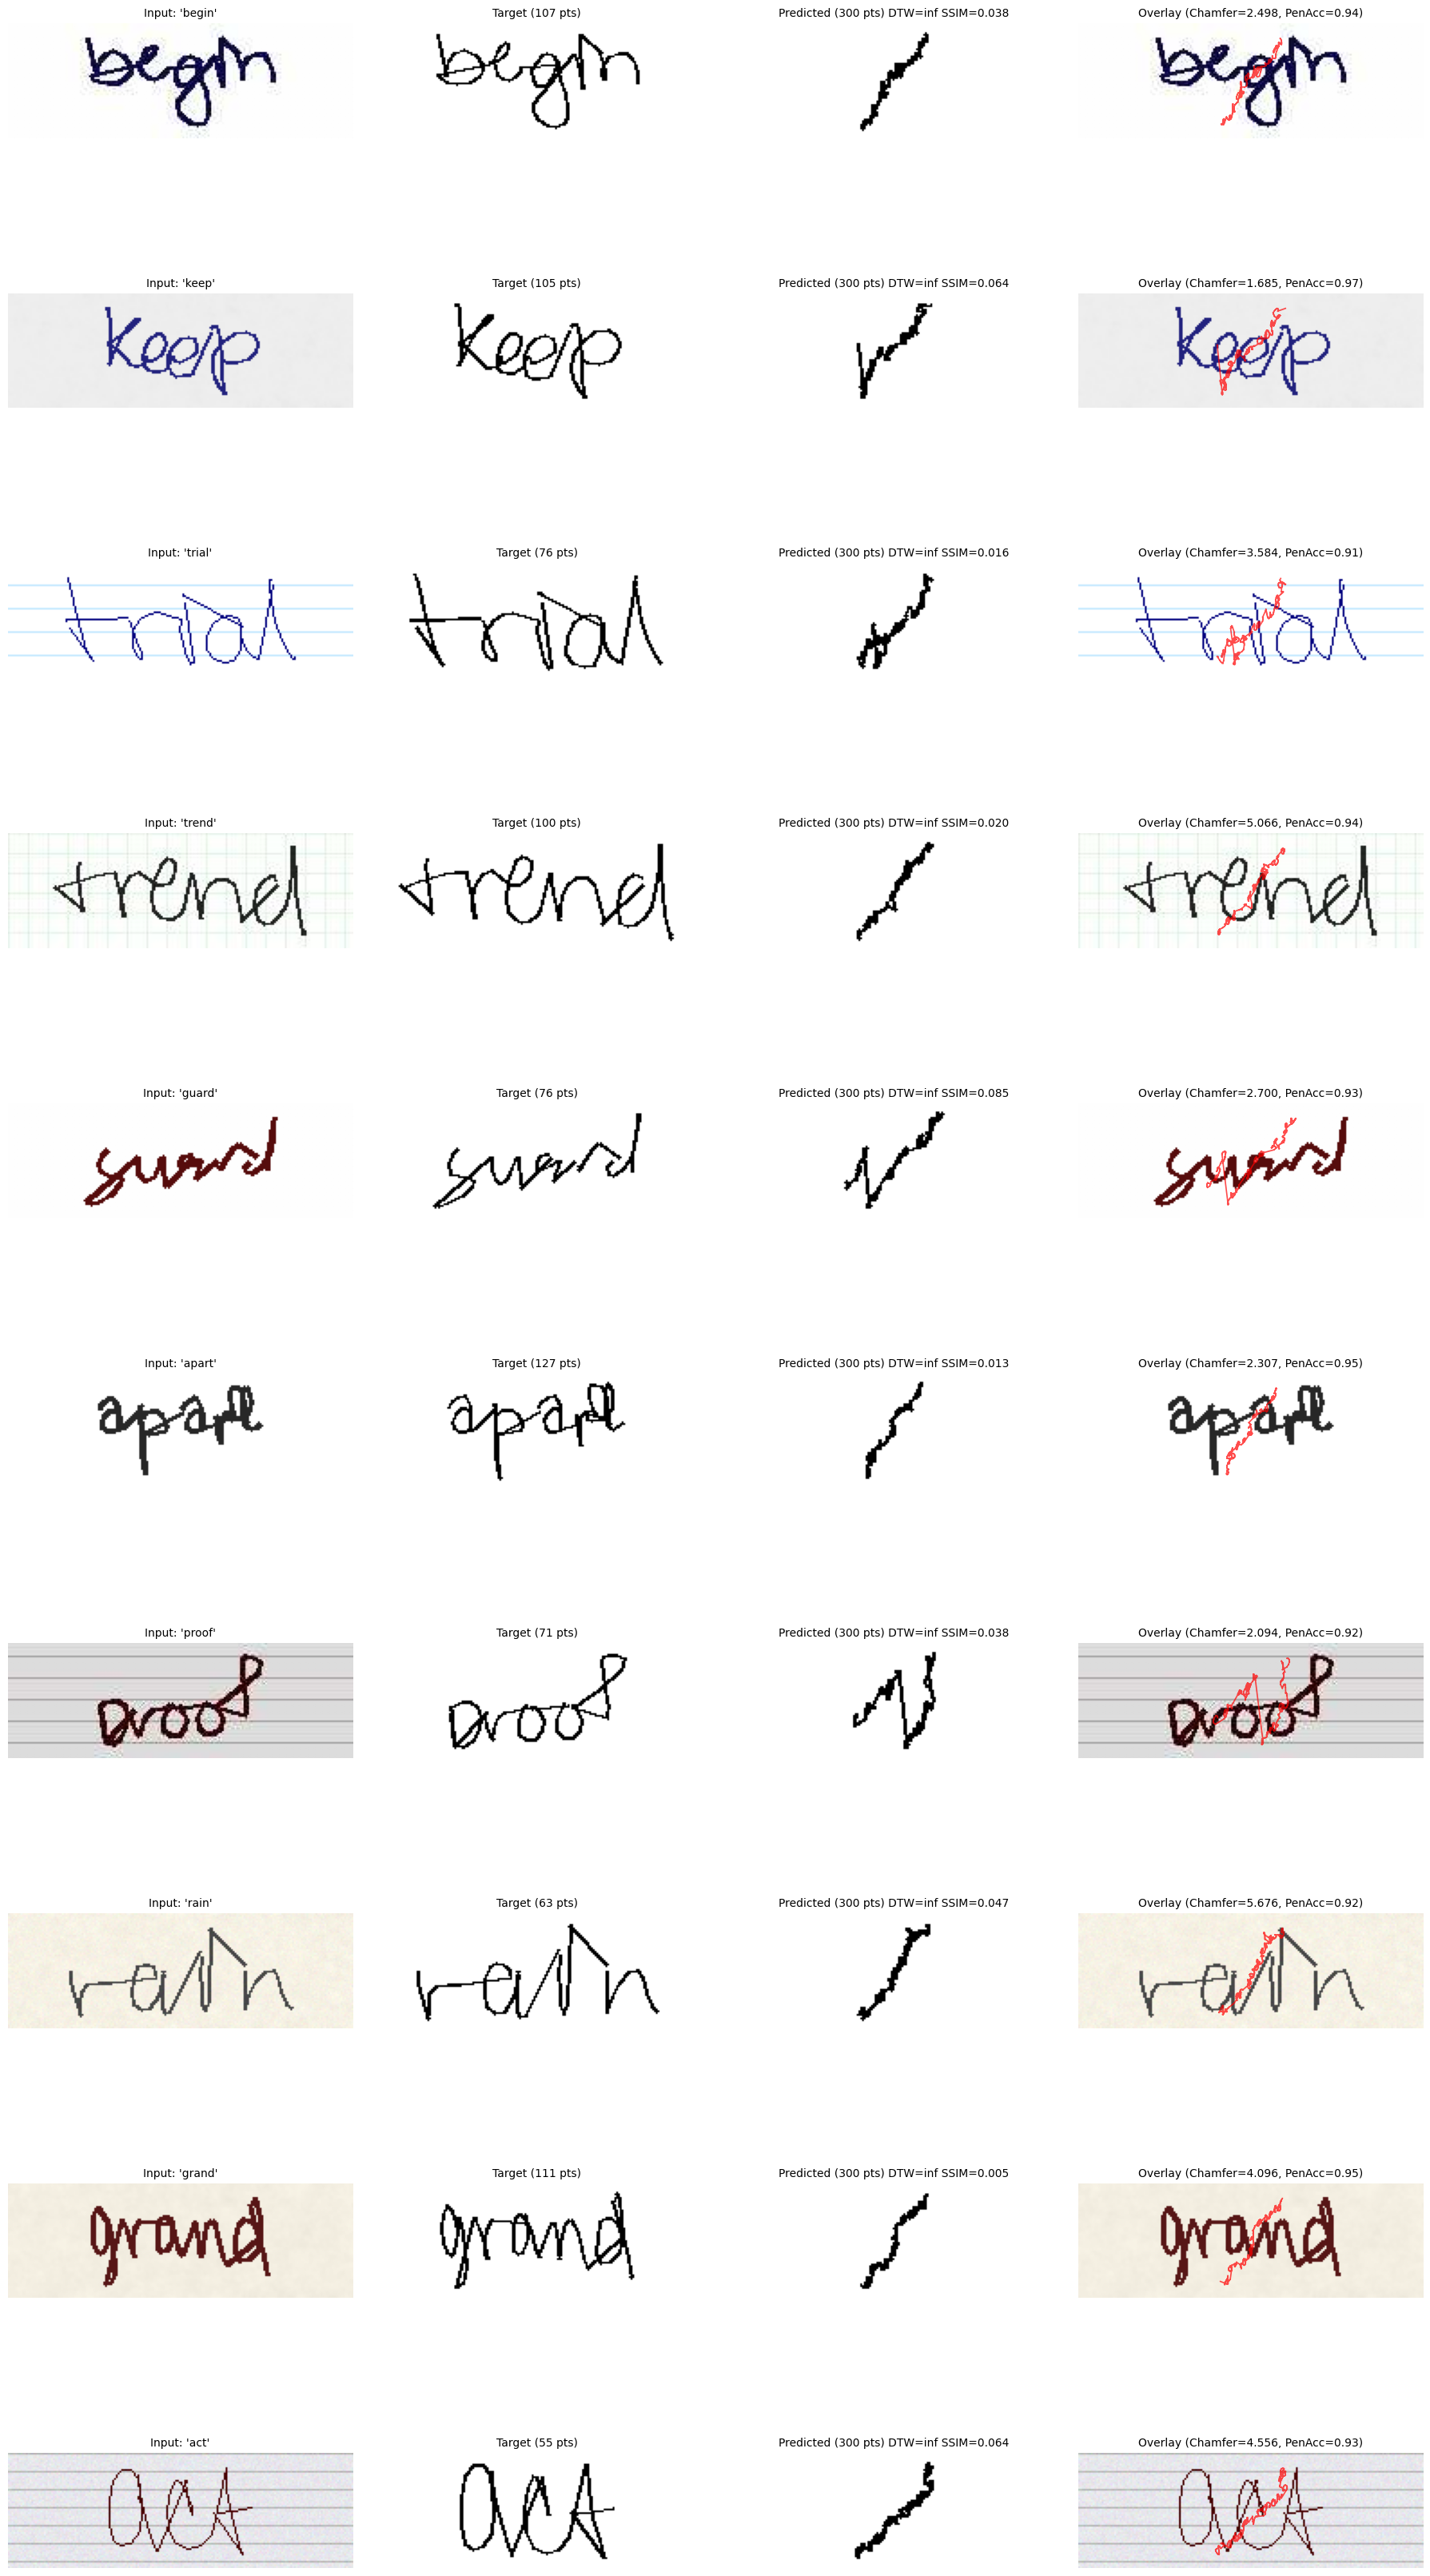

In [9]:
def overlay_trajectory(img_np, deltas, color='r', alpha=0.6, lw=1.0):
    """Plot predicted trajectory on top of the input image (in axis coords)."""
    xy = np.cumsum(deltas[:, :2], axis=0)
    pen = deltas[:, 2]
    
    H, W = img_np.shape[:2]
    xy_min = xy.min(axis=0)
    xy_max = xy.max(axis=0)
    src_w = max(xy_max[0] - xy_min[0], 1e-6)
    src_h = max(xy_max[1] - xy_min[1], 1e-6)
    
    pad = 8
    scale = min((W - 2 * pad) / src_w, (H - 2 * pad) / src_h)
    off_x = (W - src_w * scale) / 2
    off_y = (H - src_h * scale) / 2
    img_xy = (xy - xy_min) * scale + np.array([off_x, off_y])
    
    segments_x, segments_y = [], []
    for i in range(1, len(img_xy)):
        if pen[i - 1] < 0.5:
            segments_x.extend([img_xy[i-1, 0], img_xy[i, 0], np.nan])
            segments_y.extend([img_xy[i-1, 1], img_xy[i, 1], np.nan])
    return np.array(segments_x), np.array(segments_y)


@torch.no_grad()
def predict_sample(batch, temperature=1.0):
    """Run model on a single sample, return everything needed for viz."""
    image = batch["image"].to(device)
    pred_strokes, pred_lengths = model.sample(image, max_len=batch["trajectory"].shape[1], temperature=temperature)
    
    pred = pred_strokes[0].cpu().numpy()[:pred_lengths[0].item()]
    target = batch["trajectory"][0, :batch["length"][0].item()].numpy()
    img_np = batch["image"][0].permute(1, 2, 0).numpy()  # CHW → HWC
    word = batch["word"][0]
    
    metrics = compute_all_metrics(pred, target) if len(pred) >= 2 and len(target) >= 2 else {}
    return img_np, target, pred, word, metrics


# Show N random test samples
N = 10
test_iter = iter(test_loader)
fig, axes = plt.subplots(N, 4, figsize=(18, 3.5 * N))

for i in range(N):
    batch = next(test_iter)
    img_np, target, pred, word, metrics = predict_sample(batch)
    
    # Input image
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"Input: '{word}'", fontsize=10)
    axes[i, 0].axis("off")
    
    # Target trajectory
    target_render = render_trajectory(target)
    axes[i, 1].imshow(target_render, cmap="gray")
    axes[i, 1].set_title(f"Target ({len(target)} pts)", fontsize=10)
    axes[i, 1].axis("off")
    
    # Predicted trajectory
    pred_render = render_trajectory(pred)
    axes[i, 2].imshow(pred_render, cmap="gray")
    m_str = ""
    if metrics:
        m_str = f" DTW={metrics['dtw']:.3f} SSIM={metrics['ssim']:.3f}"
    axes[i, 2].set_title(f"Predicted ({len(pred)} pts){m_str}", fontsize=10)
    axes[i, 2].axis("off")
    
    # Overlay on input
    axes[i, 3].imshow(img_np)
    sx, sy = overlay_trajectory(img_np, pred, color='r')
    axes[i, 3].plot(sx, sy, 'r-', alpha=0.7, linewidth=1.2)
    if metrics:
        axes[i, 3].set_title(f"Overlay (Chamfer={metrics['chamfer']:.3f}, PenAcc={metrics['pen_accuracy']:.2f})", fontsize=10)
    else:
        axes[i, 3].set_title("Overlay", fontsize=10)
    axes[i, 3].axis("off")

plt.tight_layout()
plt.show()

## Temperature sweep

Same input image, different sampling temperatures. Lower = more deterministic, higher = more diverse.

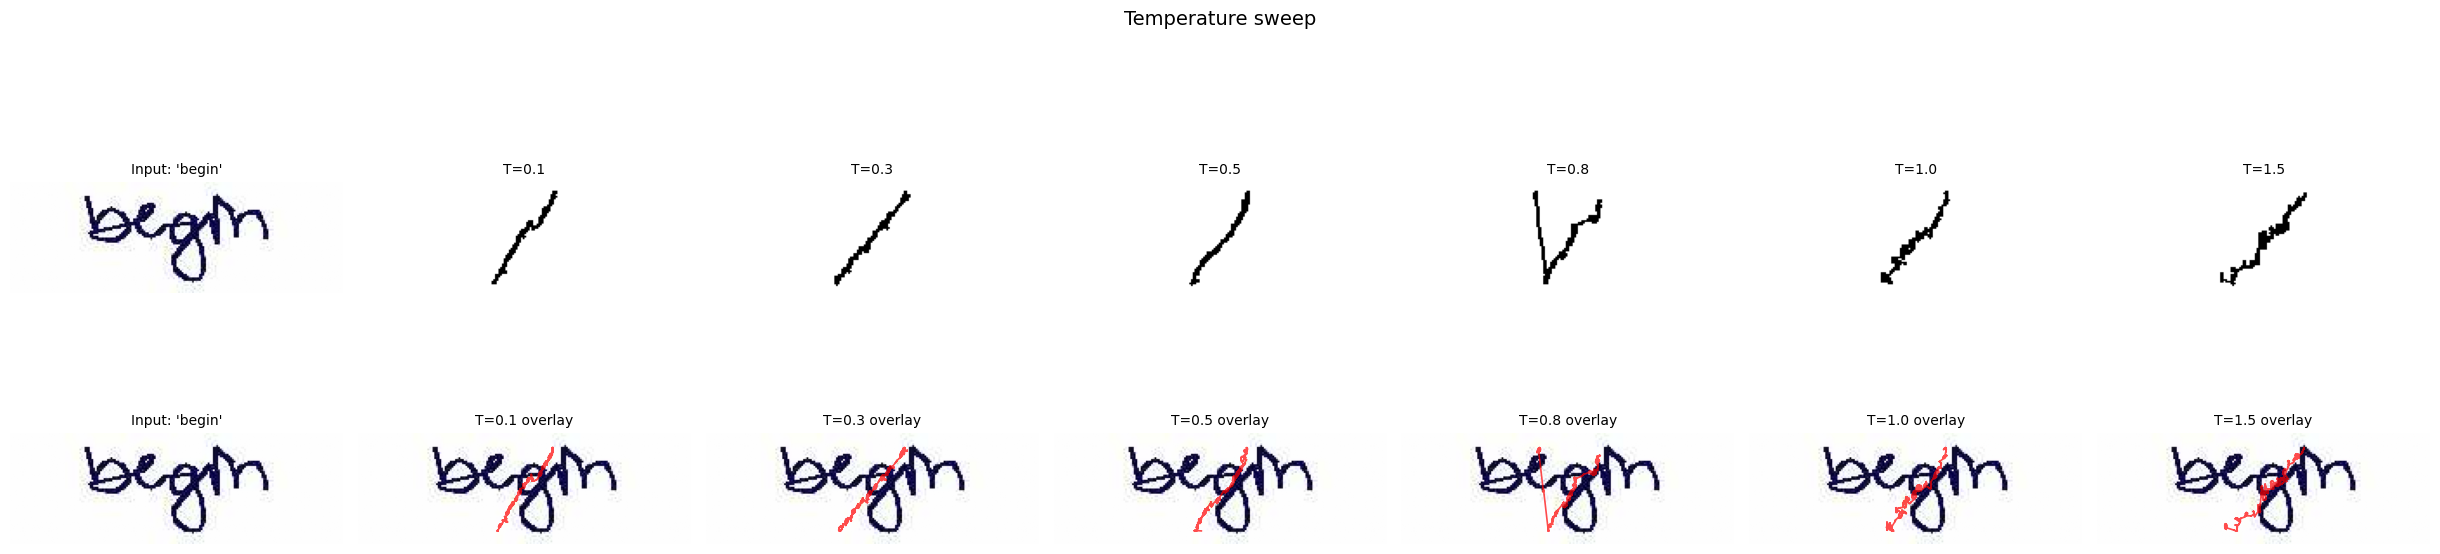

In [7]:
# Pick one test sample and generate at different temperatures
test_iter2 = iter(test_loader)
batch = next(test_iter2)
img_np = batch["image"][0].permute(1, 2, 0).numpy()
word = batch["word"][0]

temperatures = [0.1, 0.3, 0.5, 0.8, 1.0, 1.5]
fig, axes = plt.subplots(2, len(temperatures) + 1, figsize=(3.5 * (len(temperatures) + 1), 7))

# Show input in first column
for row in range(2):
    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f"Input: '{word}'", fontsize=10)
    axes[row, 0].axis("off")

for j, temp in enumerate(temperatures):
    with torch.no_grad():
        image = batch["image"].to(device)
        pred_strokes, pred_lengths = model.sample(image, max_len=batch["trajectory"].shape[1], temperature=temp)
    pred = pred_strokes[0].cpu().numpy()[:pred_lengths[0].item()]
    
    # Row 1: rendered trajectory
    pred_render = render_trajectory(pred)
    axes[0, j + 1].imshow(pred_render, cmap="gray")
    axes[0, j + 1].set_title(f"T={temp}", fontsize=10)
    axes[0, j + 1].axis("off")
    
    # Row 2: overlay on input
    axes[1, j + 1].imshow(img_np)
    sx, sy = overlay_trajectory(img_np, pred)
    axes[1, j + 1].plot(sx, sy, 'r-', alpha=0.7, linewidth=1.2)
    axes[1, j + 1].set_title(f"T={temp} overlay", fontsize=10)
    axes[1, j + 1].axis("off")

plt.suptitle("Temperature sweep", fontsize=14)
plt.tight_layout()
plt.show()

## Aggregate test metrics

In [8]:
# Compute metrics on all test samples
all_metrics = []
test_iter3 = iter(test_loader)

for batch in test_iter3:
    img_np, target, pred, word, metrics = predict_sample(batch)
    if metrics:
        all_metrics.append(metrics)

print(f"Evaluated {len(all_metrics)} test samples\n")
print(f"{'Metric':<15} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 50)
for key in ["dtw", "chamfer", "ssim", "pen_accuracy"]:
    values = [m[key] for m in all_metrics]
    print(f"{key:<15} {np.mean(values):>8.4f} {np.std(values):>8.4f} {np.min(values):>8.4f} {np.max(values):>8.4f}")

Evaluated 200 test samples

Metric              Mean      Std      Min      Max
--------------------------------------------------
dtw                  inf      nan   1.3627      inf
chamfer           3.7764   1.1245   1.3634   6.8803
ssim              0.0456   0.0480  -0.0250   0.3489
pen_accuracy      0.9365   0.0256   0.8519   0.9967
